### 1. Configuration

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_raw = pd.read_csv("population_total.csv")
df_raw.head()

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09


### 2. Making a pivot table

In [4]:
df_raw = df_raw.dropna()

In [ ]:
df_pivot = df_raw.pivot_table(
    index="year", 
    columns="country", 
    values="population"
    )

In [16]:
countries = ["United States", "India", "China", "Indonesia", "Brazil"]
df_pivot = df_pivot[countries]

In [10]:
df_pivot.head()

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,409880595.0,612241554.0,77273425.0,62533919.0
1960.0,186720571.0,450547679.0,660408056.0,87751068.0,72179226.0
1965.0,199733676.0,499123324.0,724218968.0,100267062.0,83373530.0
1970.0,209513341.0,555189792.0,827601394.0,114793178.0,95113265.0
1975.0,219081251.0,623102897.0,926240885.0,130680727.0,107216205.0


### 3. Lineplot

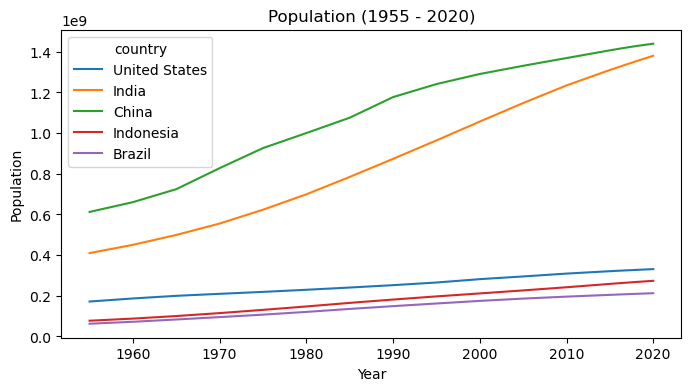

In [60]:
df_pivot.plot(
    kind="line", 
    xlabel="Year", 
    ylabel="Population",
    title="Population (1955 - 2020)",
    figsize=(8,4)
    )

plt.savefig("01_lineplot.png")
plt.show()

In [61]:
df_pivot.to_excel("pivot_table.xlsx")

### 4. Barplot

#### 4.1. Single barplot

In [23]:
filter = df_pivot.index.isin([2020]) # only year 2020
df_pivot_2020 = df_pivot[filter]

df_pivot_2020.head()

country,United States,India,China,Indonesia,Brazil
year,,,,,
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


In [25]:
df_pivot_2020 = df_pivot_2020.T
df_pivot_2020

year,2020.0
country,
United States,3.310027e+08
India,1.380004e+09
China,1.439324e+09
Indonesia,2.735236e+08
Brazil,2.125594e+08


<Axes: title={'center': 'Population (2020)'}, xlabel='Country', ylabel='Population'>

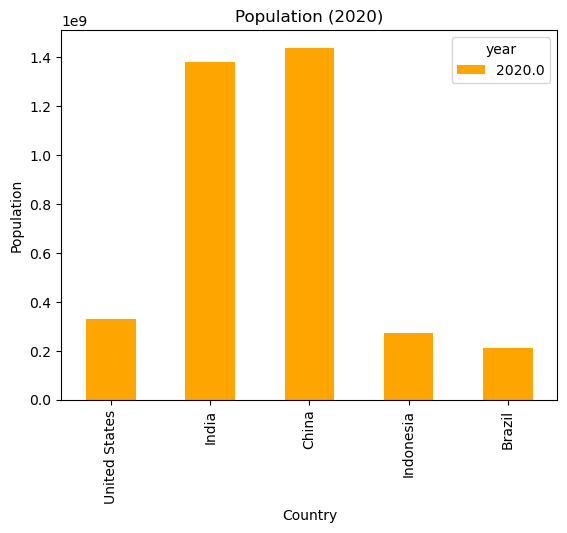

In [28]:
df_pivot_2020.plot(
    kind="bar",
    color="orange",
    xlabel="Country",
    ylabel="Population",
    title="Population (2020)"
    )

#### 4.2. Barplot grouped by "n" variables

In [ ]:
filter = df_pivot.index.isin([1980, 1990, 2000, 2010, 2020])
df_pivot_sample = df_pivot[filter]

df_pivot_sample.head()

country,United States,India,China,Indonesia,Brazil
year,,,,,
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
2000.0,281710909.0,1.056576e+09,1.290551e+09,211513823.0,174790340.0
2010.0,309011475.0,1.234281e+09,1.368811e+09,241834215.0,195713635.0
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


<Axes: title={'center': 'Population (1980 - 2020)'}, xlabel='Year', ylabel='Population'>

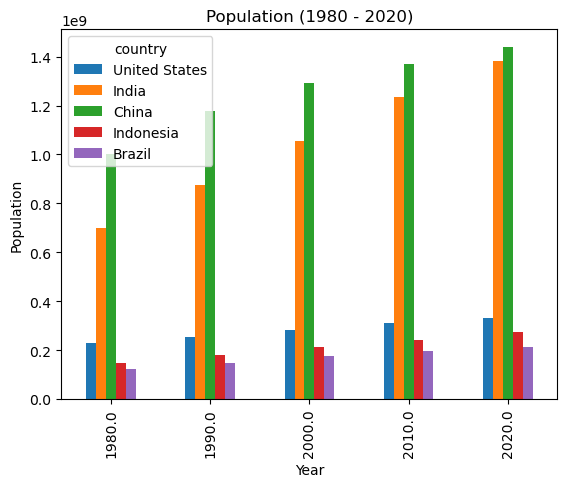

In [34]:
df_pivot_sample.plot(
    kind="bar",
    xlabel="Year",
    ylabel="Population",
    title="Population (1980 - 2020)"
    )

### 5. Piechart

In [37]:
df_pivot_2020.head()

year,2020.0
country,
United States,3.310027e+08
India,1.380004e+09
China,1.439324e+09
Indonesia,2.735236e+08
Brazil,2.125594e+08


In [40]:
df_pivot_2020 = df_pivot_2020.rename(columns={2020:"2020"})
df_pivot_2020.head()

year,2020
country,
United States,3.310027e+08
India,1.380004e+09
China,1.439324e+09
Indonesia,2.735236e+08
Brazil,2.125594e+08


<Axes: title={'center': 'Population 2020 [%]'}, ylabel='2020'>

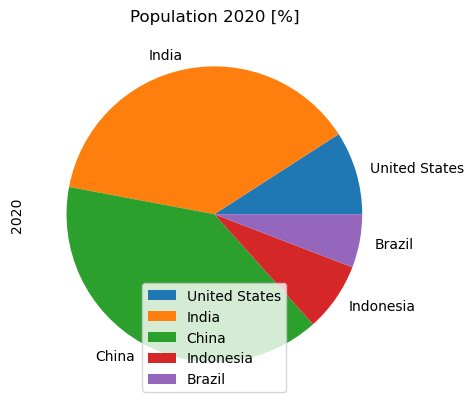

In [43]:
df_pivot_2020.plot(
    kind="pie",
    y="2020",
    title="Population 2020 [%]")

### 6. Boxplot

#### 6.1. Single Boxplot

In [44]:
df_pivot.head()

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,409880595.0,612241554.0,77273425.0,62533919.0
1960.0,186720571.0,450547679.0,660408056.0,87751068.0,72179226.0
1965.0,199733676.0,499123324.0,724218968.0,100267062.0,83373530.0
1970.0,209513341.0,555189792.0,827601394.0,114793178.0,95113265.0
1975.0,219081251.0,623102897.0,926240885.0,130680727.0,107216205.0


<Axes: ylabel='Population'>

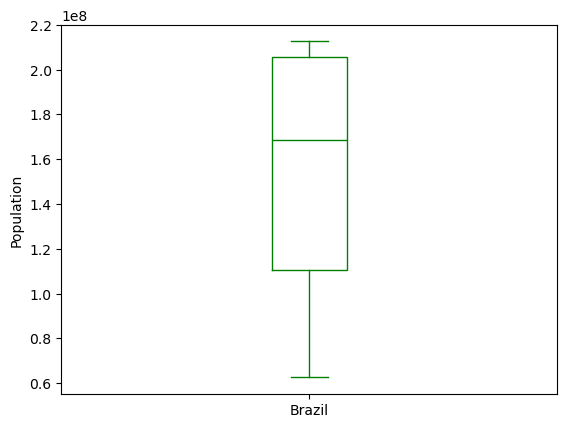

In [ ]:
df_pivot["Brazil"].plot(kind="box",
                        color="green",
                        ylabel="Population")

#### 6.2. Multiple Boxplot

<Axes: ylabel='Population'>

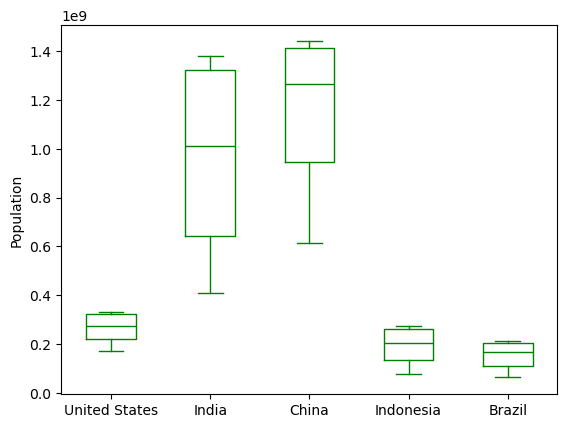

In [ ]:
df_pivot.plot(kind="box",
              color="green",
              ylabel="Population"
              )

### 7. Histogram

<Axes: ylabel='Frequency'>

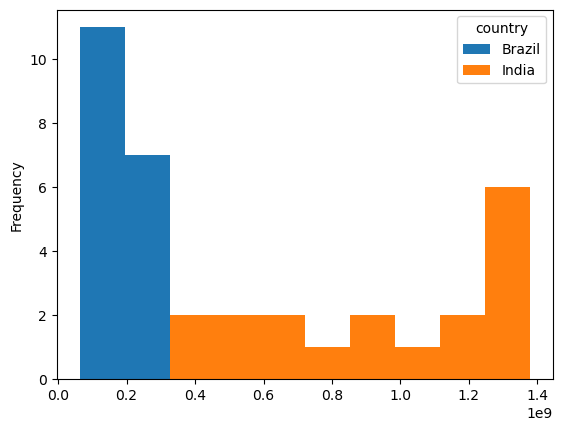

In [50]:
df_pivot[["Brazil", "India"]].plot(kind="hist")

### 8. ScatterPlot

In [54]:
countries = ["United States", "Brazil", "India", "China", "Indonesia"]
filter = df_raw["country"].isin(countries)

df_sample = df_raw[filter]
df_sample.head()

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09


<Axes: xlabel='year', ylabel='population'>

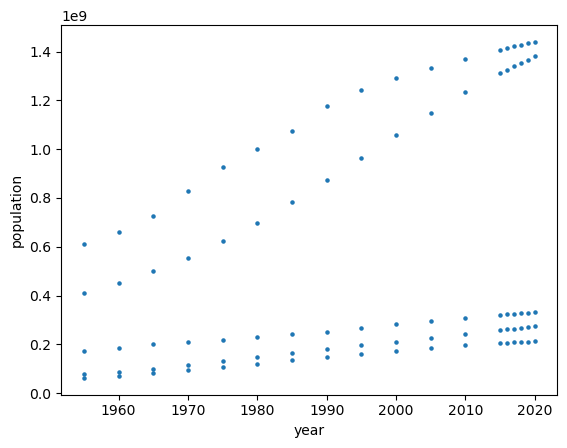

In [ ]:
df_sample.plot(
    kind="scatter",
    x="year",
    y="population",
    s=5
    )

### 9. Interactive Visualization

In [ ]:
!pip install plotly

In [ ]:
!pip install cufflinks

In [64]:
import pandas as pd
import cufflinks as cf
from IPython.display import display, HTML

cf.set_config_file(sharing="public", theme="ggplot", offline=True)

In [65]:
cf.getThemes()

['ggplot', 'pearl', 'solar', 'space', 'white', 'polar', 'henanigans']

#### 9.1. Interactive Lineplot

In [67]:
df_pivot.head()

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,409880595.0,612241554.0,77273425.0,62533919.0
1960.0,186720571.0,450547679.0,660408056.0,87751068.0,72179226.0
1965.0,199733676.0,499123324.0,724218968.0,100267062.0,83373530.0
1970.0,209513341.0,555189792.0,827601394.0,114793178.0,95113265.0
1975.0,219081251.0,623102897.0,926240885.0,130680727.0,107216205.0


In [73]:
df_pivot.iplot(
    kind="line",
    xTitle="Years",
    yTitle="Population",
    title="Population 1955 - 2020")

#### 9.2. Interactive Barplot

In [74]:
df_pivot_2020.head()

year,2020
country,
United States,3.310027e+08
India,1.380004e+09
China,1.439324e+09
Indonesia,2.735236e+08
Brazil,2.125594e+08


In [77]:
df_pivot_2020.iplot(
    kind="bar",
    xTitle="Years",
    yTitle="Population",
    title="Population 2020",
    dimensions=(800,400)
    )

#### 9.3. Interactive Barplot (Multiple variables)

In [81]:
df_pivot_sample.head()

country,United States,India,China,Indonesia,Brazil
year,,,,,
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
2000.0,281710909.0,1.056576e+09,1.290551e+09,211513823.0,174790340.0
2010.0,309011475.0,1.234281e+09,1.368811e+09,241834215.0,195713635.0
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


In [80]:
df_pivot_sample.iplot(
    kind="bar",
    xTitle="Years",
    yTitle="Population",
    title="Population 2020",
    dimensions=(800,400)
    )

#### 9.4. Interactive Piechart

In [83]:
df_pivot_2020 = df_pivot_2020.reset_index()

In [ ]:
df_pivot_2020.iplot(
    kind="pie",
    values="2020",
    labels="country",
    title="Population 2020",
    dimensions=(400,400)
    )

#### 9.5. Interactive Boxplot

In [86]:
df_pivot.head()

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,409880595.0,612241554.0,77273425.0,62533919.0
1960.0,186720571.0,450547679.0,660408056.0,87751068.0,72179226.0
1965.0,199733676.0,499123324.0,724218968.0,100267062.0,83373530.0
1970.0,209513341.0,555189792.0,827601394.0,114793178.0,95113265.0
1975.0,219081251.0,623102897.0,926240885.0,130680727.0,107216205.0


In [90]:
df_pivot["Brazil"].iplot(
    kind="box",
    xTitle="Country",
    yTitle="Population",
    title="Population 1955 - 2020",
    dimensions=(400,600)
    )

In [92]:
df_pivot.iplot(
    kind="box",
    xTitle="Country",
    yTitle="Population",
    title="Population 1955 - 2020",
    dimensions=(800,600)
    )

#### 9.6. Interactive Histogram

In [95]:
df_pivot["Brazil"].iplot(
    kind="hist",
    bins=3,
    dimensions=(800,600)
    )

In [96]:
df_pivot[["Brazil", "Indonesia"]].iplot(
    kind="hist",
    bins=3,
    dimensions=(800,600)
    )

#### 9.7. Interactive Scatterplot

In [ ]:
df_pivot.iplot(
    kind="scatter",
    mode="markers",
    dimensions=(800,400)
    )